# Investigating Data Leakage in Loan Default Prediction

### Lending Club Loan Dataset, 2007–2018

This project investigates how data leakage can artificially inflate the performance of a machine learning model for loan default prediction.

Three feature conditions are compared:

1. Clean model: uses information available at loan origination.
2. Temporal leakage model: adds information generated after loan origination.
3. Strong leakage model: adds multiple post-origination variables.

The objective is to measure how much model performance changes when information that would not have been available at prediction time is introduced.

## 1. Load the Dataset

This cell imports the libraries required for data handling and machine learning, then loads the Lending Club dataset from the compressed CSV file.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

dataset_path = "data/accepted_2007_to_2018Q4.csv.gz"

df = pd.read_csv(
    dataset_path,
    compression="gzip",
    low_memory=False
)

print("Dataset shape:", df.shape)

Dataset shape: (2260701, 151)


## 2. Define the Prediction Target and Feature Sets

The analysis focuses on two final loan outcomes: **Fully Paid** and **Charged Off**.

These are converted into a binary target where 0 represents a fully paid loan and 1 represents a charged-off loan.

Three feature sets are then created to compare normal prediction with different levels of data leakage.

In [39]:
df = df[
    df["loan_status"].isin(["Fully Paid", "Charged Off"])
].copy()

df["target"] = (df["loan_status"] == "Charged Off").astype(int)

clean_features = [
    "loan_amnt", "int_rate", "annual_inc", "dti",
    "fico_range_low", "fico_range_high",
    "emp_length", "home_ownership",
    "verification_status", "purpose"
]

temporal_features = clean_features + [
    "last_fico_range_low"
]

strong_features = temporal_features + [
    "total_pymnt", "recoveries", "last_pymnt_amnt"
]

experiment_df = df[
    strong_features + ["target"]
].copy()

## 3. Prepare the Data for Modeling

The dataset is divided into training and testing sets using the same split for all three experiments.

The preprocessing pipeline handles missing values, scales numerical variables, and converts categorical variables into numerical form. Keeping the same split and preprocessing approach allows the three models to be compared fairly.

In [40]:
train_idx, test_idx = train_test_split(
    experiment_df.index,
    test_size=0.20,
    random_state=42,
    stratify=experiment_df["target"]
)

y = experiment_df["target"]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

numeric_features = [
    "loan_amnt", "int_rate", "annual_inc", "dti",
    "fico_range_low", "fico_range_high",
    "last_fico_range_low", "total_pymnt",
    "recoveries", "last_pymnt_amnt"
]

categorical_features = [
    "emp_length", "home_ownership",
    "verification_status", "purpose"
]

preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        numeric_features
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

## 4. Train the Models

Three logistic regression models are trained using the same training observations:

- Clean: uses only information available at loan origination.
- Temporal leakage: adds a variable containing information generated later in the loan lifecycle.
- Strong leakage: adds several variables that reflect subsequent loan performance.

This allows the effect of data leakage on model performance to be measured directly.

In [41]:
models = {}

for name, features in {
    "Clean": clean_features,
    "Temporal leakage": temporal_features,
    "Strong leakage": strong_features
}.items():

    numeric = [f for f in features if f in numeric_features]
    categorical = [f for f in features if f in categorical_features]

    prep = ColumnTransformer([
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical
        )
    ])

    model = Pipeline([
        ("preprocessor", prep),
        ("classifier", LogisticRegression(max_iter=1000))
    ])

    X_train = experiment_df.loc[train_idx, features]
    model.fit(X_train, y_train)

    models[name] = model

## 5. Evaluate Model Performance

Each model is evaluated on the same unseen test set using ROC-AUC and accuracy.

ROC-AUC measures how well the model distinguishes between fully paid and charged-off loans, while accuracy measures the proportion of test observations classified correctly.

In [42]:
results = []

for name, model in models.items():

    X_test = experiment_df.loc[test_idx, {
        "Clean": clean_features,
        "Temporal leakage": temporal_features,
        "Strong leakage": strong_features
    }[name]]

    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    auc = roc_auc_score(y_test, prob)
    accuracy = accuracy_score(y_test, pred)

    results.append([
        name,
        auc,
        accuracy
    ])

results = pd.DataFrame(
    results,
    columns=["Condition", "ROC-AUC", "Accuracy"]
)

results["AUC increase vs Clean"] = (
    results["ROC-AUC"] - results.loc[0, "ROC-AUC"]
)

results.round(4)

,Condition,ROC-AUC,Accuracy,AUC increase vs Clean
0,Clean,0.6962,0.8007,0.0000
1,Temporal leakage,0.9446,0.8977,0.2485
2,Strong leakage,0.9978,0.9916,0.3016


## 6. Compare Model Performance

The following visualization compares ROC-AUC across the three feature conditions. A large increase in performance after introducing post-origination information provides evidence of the effect of data leakage.

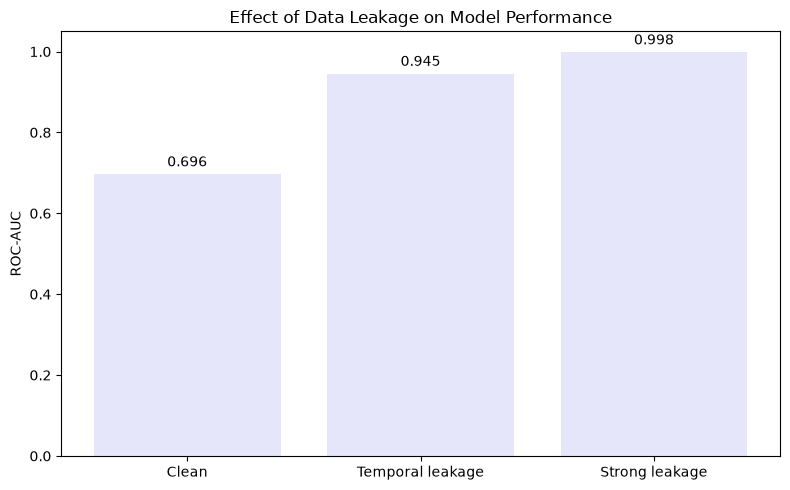

In [53]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    results["Condition"],
    results["ROC-AUC"],
    color="lavender"
)

plt.ylabel("ROC-AUC")
plt.title("Effect of Data Leakage on Model Performance")
plt.ylim(0, 1.05)

for bar, value in zip(bars, results["ROC-AUC"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Examine the Leakage Features

The leakage variables are compared across the two loan outcomes using their median values.

These variables contain information generated during the later stages of a loan, so large differences between the two outcome groups help explain why including them can substantially improve apparent model performance.

In [44]:
leakage_features = [
    "last_fico_range_low",
    "total_pymnt",
    "recoveries",
    "last_pymnt_amnt"
]

leakage_summary = (
    experiment_df
    .groupby("target")[leakage_features]
    .median()
    .rename(index={
        0: "Fully Paid",
        1: "Charged Off"
    })
)

leakage_summary

,last_fico_range_low,total_pymnt,recoveries,last_pymnt_amnt
target,,,,
Fully Paid,705.0,13842.117953,0.0,4116.09
Charged Off,555.0,6517.930000,592.2,389.98


## 8. ROC Curve Comparison

The ROC curves provide a visual comparison of model discrimination under the three feature conditions.

The comparison shows how introducing information generated after loan origination changes the apparent predictive performance.

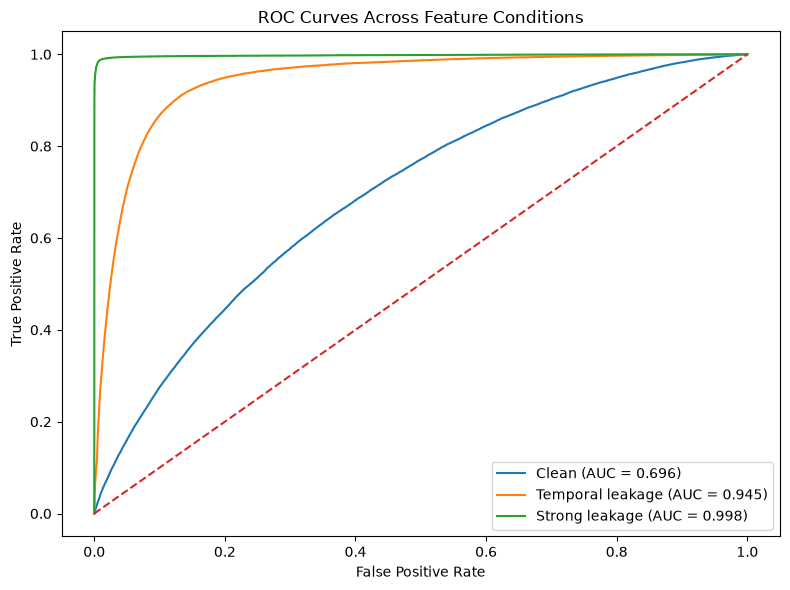

In [56]:
# ROC curves
plt.figure(figsize=(8, 6))

for name, model in models.items():

    features = {
        "Clean": clean_features,
        "Temporal leakage": temporal_features,
        "Strong leakage": strong_features
    }[name]

    X_test = experiment_df.loc[test_idx, features]
    prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Across Feature Conditions")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Conclusion

The clean model achieved a ROC-AUC of 0.696, providing the baseline performance using information available at loan origination.

Introducing the temporal leakage feature increased ROC-AUC to 0.945, while the strong leakage model achieved a ROC-AUC of 0.998.

The results demonstrate that using information generated after the prediction point can substantially inflate the apparent performance of a machine learning model. Variables such as `recoveries`, `total_pymnt`, and `last_pymnt_amnt` are particularly problematic because they describe events occurring during the later lifecycle of the loan.

Therefore, when developing a model for loan default prediction, features must be restricted to information that would actually be available at the intended prediction time.